In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
base_path = "/content/drive/MyDrive/GDA_Project/"

In [3]:
import pandas as pd

tumor = pd.read_csv(base_path+"BC-TCGA-Tumor.txt", sep="\t", index_col=0)
normal = pd.read_csv(base_path+"BC-TCGA-Normal.txt", sep="\t", index_col=0)

In [27]:
print("Normal:", normal.shape)
print("Tumor:", tumor.shape)

Normal: (17814, 61)
Tumor: (17814, 529)


In [4]:
common_genes = tumor.index.intersection(normal.index)

tumor = tumor.loc[common_genes]
normal = normal.loc[common_genes]

In [5]:
tumor.columns = ["Tumor_" + col for col in tumor.columns]
normal.columns = ["Normal_" + col for col in normal.columns]

combined = pd.concat([tumor, normal], axis=1)

In [26]:
combined.to_csv("combined_expression.csv")


In [8]:
tf_list = pd.read_csv(base_path+"Homo_sapiens_TF.txt", header=None)[0].tolist()

tf_in_data = list(set(tf_list).intersection(combined.index))

tf_data = combined.loc[tf_in_data]

tf_data.to_csv("filtered_TF_expression.csv")

In [9]:
labels = ["Tumor"] * tumor.shape[1] + ["Normal"] * normal.shape[1]

In [17]:
import pandas as pd
import numpy as np

combined = pd.read_csv(base_path+"combined_expression.csv", index_col=0)
tf_list = pd.read_csv(base_path+"Homo_sapiens_TF.txt", header=None)[0].tolist()

In [18]:
tumor_cols = [c for c in combined.columns if c.startswith("Tumor")]
normal_cols = [c for c in combined.columns if c.startswith("Normal")]

tumor = combined[tumor_cols]
normal = combined[normal_cols]

In [19]:
tumor = tumor.fillna(0)
normal = normal.fillna(0)

In [20]:
print("Tumor min:", tumor.min().min())
print("Normal min:", normal.min().min())

Tumor min: -11.785
Normal min: -9.8855


In [21]:
#variance filtering
variance = combined.var(axis=1)

# Keep genes above small threshold
filtered_genes = variance[variance > 0.1].index

combined = combined.loc[filtered_genes]

In [23]:
print("Remaining genes:", combined.shape[0])

Remaining genes: 17491


In [28]:
print("Genes after variance filtering:", len(filtered_genes))


Genes after variance filtering: 17491


Initially we had 17814 genes which became 17491 genes after variance filtering. 323 genes are filtered.

In [29]:
from scipy.stats import ttest_ind

# STEP 5: Differential Expression
results = []

for gene in combined.index:
    tumor_vals = tumor.loc[gene]
    normal_vals = normal.loc[gene]

    # skip problematic genes
    if np.isnan(tumor_vals).any() or np.isnan(normal_vals).any():
        continue

    t_stat, p_val = ttest_ind(tumor_vals, normal_vals, equal_var=False)

    # ✅ CORRECT for log-transformed TCGA data
    log_fc = tumor_vals.mean() - normal_vals.mean()

    results.append([gene, log_fc, p_val])

In [30]:
# STEP 6: Create DEG DataFrame
deg = pd.DataFrame(results, columns=["gene", "log2FC", "pval"])


In [32]:
from statsmodels.stats.multitest import multipletests

# STEP 7: Multiple Testing Correction (FDR)
deg["adj_pval"] = multipletests(deg["pval"], method='fdr_bh')[1]
display(deg.head())

,gene,log2FC,pval,adj_pval
0,ELMO2,0.574307,5.960232e-13,2.465715e-12
1,CREB3L1,0.910229,8.128325e-21,7.554332e-20
2,RPS11,-0.505878,3.510740e-11,1.219590e-10
3,PNMA1,-0.304250,4.554222e-05,8.886422e-05
4,MMP2,-0.204271,1.203030e-01,1.518634e-01


In [33]:
print(deg["log2FC"].describe())

count    17491.000000
mean        -0.015560
std          0.727063
min         -4.647682
25%         -0.298141
50%          0.045401
75%          0.364792
max          5.224134
Name: log2FC, dtype: float64


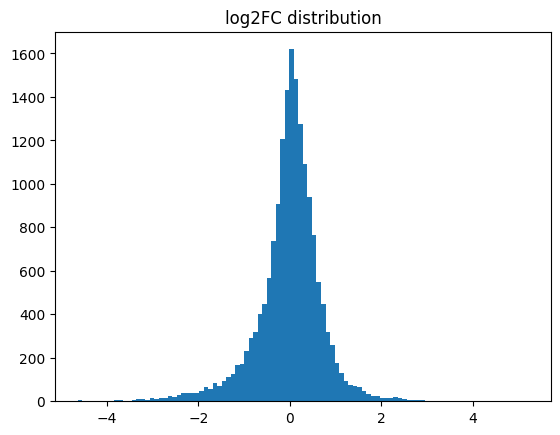

In [34]:
import matplotlib.pyplot as plt

plt.hist(deg["log2FC"], bins=100)
plt.title("log2FC distribution")
plt.show()

In [36]:
#STEP 8: Filtering DEGs
deg_filtered = deg[
    (abs(deg["log2FC"]) > 0.5) &
    (deg["adj_pval"] < 0.05)
]

print("DEGs:", len(deg_filtered))

DEGs: 6097


In [38]:
#saving filtered DEGs
deg_filtered.to_csv("DEG_filtered.csv", index=False)

In [42]:
#STEP 9: Extract TFs from DEGs

tf_data = pd.read_csv(base_path+"filtered_TF_expression.csv", index_col=0)

tf_genes = list(tf_data.index)
print("Total TFs available:", len(tf_genes))

Total TFs available: 0


In [43]:
print(tf_data.shape)

(0, 590)


In [44]:
base_path = "/content/drive/MyDrive/GDA_Project/"

combined = pd.read_csv(base_path+"combined_expression.csv", index_col=0)
tf_list = pd.read_csv(base_path+"Homo_sapiens_TF.txt", header=None)[0].tolist()

In [45]:
print("Combined genes sample:", list(combined.index)[:5])
print("TF list sample:", tf_list[:5])

Combined genes sample: ['ELMO2', 'CREB3L1', 'RPS11', 'PNMA1', 'MMP2']
TF list sample: ['Species\tSymbol\tEnsembl\tFamily\tProtein\tEntrez_ID', 'Homo_sapiens\tATF1\tENSG00000123268\tTF_bZIP\tENSP00000262053.3;\t466', 'Homo_sapiens\t\tENSG00000254553\tZBTB\tENSP00000455300.1;ENSP00000455300.1;\tNA', 'Homo_sapiens\tSOX3\tENSG00000134595\tHMG\tENSP00000359567.2;\t6658', 'Homo_sapiens\tSPIB\tENSG00000269404\tETS\tENSP00000391877.2;ENSP00000471921.1;\t6689']
